<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW2/HW2_LanguageProcessing_RNN_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt


from torchinfo import summary

In [2]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#hyperparameters
lr = 1e-4
epochs = 30
input_lengths = [20,30, 50]
hidden_size = 100
dropout_rate = 0.3

device

device(type='cuda', index=0)

In [3]:

#Imported directly from Dr. Tabkhi's Github
# Step 1: Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text  # This is the entire text data
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
def createTrainAndTestLoaders(sequence_length):



  # Encode the text into integers
  encoded_text = [char_to_int[ch] for ch in text]

  # Create sequences and targets
  sequences = []
  targets = []
  for i in range(0, len(encoded_text) - sequence_length):
      seq = encoded_text[i:i+sequence_length]
      target = encoded_text[i+sequence_length]
      sequences.append(seq)
      targets.append(target)

  # Convert lists to PyTorch tensors
  sequences = torch.tensor(sequences, dtype=torch.long)
  targets = torch.tensor(targets, dtype=torch.long)

  # Step 3: Create a dataset class
  class CharDataset(Dataset):
      def __init__(self, sequences, targets):
          self.sequences = sequences
          self.targets = targets

      def __len__(self):
          return len(self.sequences)

      def __getitem__(self, index):
          return self.sequences[index], self.targets[index]

  # Instantiate the dataset
  dataset = CharDataset(sequences, targets)

  # Step 4: Create data loaders
  batch_size = 1024
  train_size = int(len(dataset) * 0.8)
  test_size = len(dataset) - train_size
  train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

  train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size, pin_memory=True)
  test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size, pin_memory=True)

  if(train_loader and test_loader):
    print(f"Train and Test Loader Created - Sequence Length: {sequence_length}")
    return train_loader, test_loader
  else:
    print("Not created")

  # Now `train_loader` and `test_loader` are ready to be used in a training loop

In [4]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text)}")
sorted_text = list(sorted(set(text)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 1115394
Total Unique Characters: 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


In [5]:
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(LSTM,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, batch_first = True, num_layers=2, dropout=dropout_rate)
    self.dropout = nn.Dropout(p = dropout_rate)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.lstm(embedded)
    output = self.dropout(output[:, -1, :])
    output = self.fc1(output)
    return output

class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(GRU,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.gru = nn.GRU(input_size = hidden_size, hidden_size=hidden_size, batch_first = True, num_layers=2, dropout = dropout_rate)
    self.dropout = nn.Dropout(p = dropout_rate)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.gru(embedded)
    output = self.dropout(output[:, -1, :])
    output = self.fc1(output)
    return output

In [6]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

In [7]:
def createMODELandLOSS(model):
  model = model.upper()
  valid_models = {'RNN', 'LSTM', 'GRU'}
  if model not in valid_models:
    raise ValueError(f"Invalid Type {model}. Expected one of {valid_models}")
  if(model == "RNN"):
    model = RNN(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "LSTM"):
    model = LSTM(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "GRU"):
    model = GRU(len(sorted_text), hidden_size, len(sorted_text)).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = lr)
  return model, criterion, optimizer

In [16]:
def run(modelName):
##Data Preprocessing and converting to tensor
  for i, input_length in enumerate(input_lengths):

    train_loader, test_loader = createTrainAndTestLoaders(input_length)
    model, criterion, optimizer = createMODELandLOSS(modelName)

    ###This is where training begins
    #Lists for storing loss and validation values
    train_loss_list = []
    val_loss_list = []
    val_accuracy_list = []

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    #Create a new training loop for each input_length
    for epoch in range(epochs):
      start_event.record()
      model.train()

      for data in train_loader:
        X_train, y_train = data
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        optimizer.zero_grad()
        y_pred = model(X_train)  # Forward pass
        loss = criterion(y_pred, y_train)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update model parameters




      end_event.record()
      torch.cuda.synchronize()
      elapsed_time_ms = start_event.elapsed_time(end_event)
      train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                          #to the training loss list (of all epochs)


      #Here is where we evaluate the model on the current epoch
      model.eval()
      with torch.no_grad():
        for data in test_loader:
          X_val, y_val = data
          X_val = X_val.to(device)
          y_val = y_val.to(device)
          val_output = model(X_val) # Take test dataset and run it through this epoch's model

          val_loss = criterion(val_output, y_val) #Find the loss

          _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

          val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from out model,
                                                            #compare it to the ground truth, and find how accurate we are

        val_loss_list.append(val_loss.item())
        val_accuracy_list.append(val_accuracy.item())


        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}, Training Time: {elapsed_time_ms}ms')

    createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
    print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))


Train and Test Loader Created - Sequence Length: 20
Epoch 0, Loss: 2.7177, Val Accuracy: 0.2768, Val Loss: 2.7014, Training Time: 7354.87060546875ms
Epoch 1, Loss: 2.4821, Val Accuracy: 0.3414, Val Loss: 2.3953, Training Time: 9141.2138671875ms
Epoch 2, Loss: 2.3771, Val Accuracy: 0.3691, Val Loss: 2.2667, Training Time: 8962.3798828125ms
Epoch 3, Loss: 2.3079, Val Accuracy: 0.3922, Val Loss: 2.1780, Training Time: 8870.169921875ms
Epoch 4, Loss: 2.2760, Val Accuracy: 0.4025, Val Loss: 2.1086, Training Time: 8807.185546875ms
Epoch 5, Loss: 2.0151, Val Accuracy: 0.4210, Val Loss: 2.0494, Training Time: 8915.5322265625ms
Epoch 6, Loss: 2.2008, Val Accuracy: 0.4371, Val Loss: 2.0005, Training Time: 8744.259765625ms
Epoch 7, Loss: 2.0044, Val Accuracy: 0.4429, Val Loss: 1.9651, Training Time: 8792.041015625ms
Epoch 8, Loss: 2.0917, Val Accuracy: 0.4464, Val Loss: 1.9302, Training Time: 8832.9052734375ms
Epoch 9, Loss: 1.9411, Val Accuracy: 0.4521, Val Loss: 1.9030, Training Time: 8835.8027

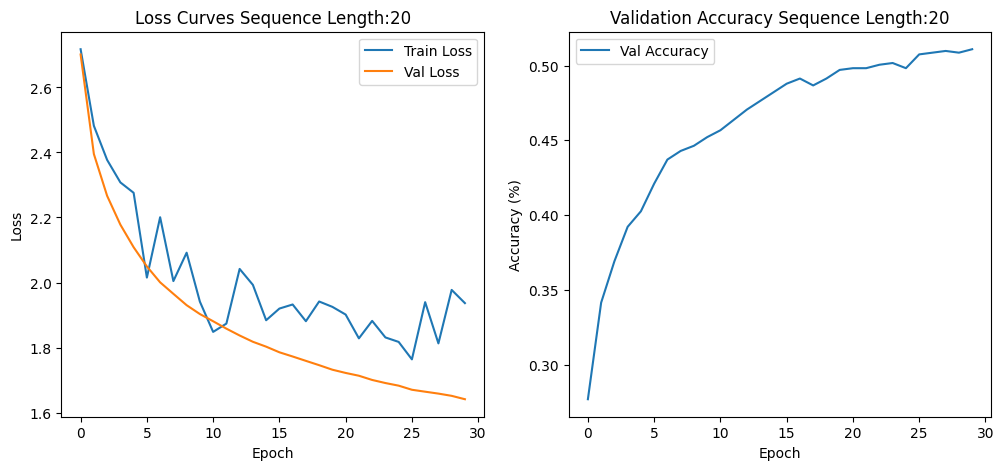

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 65]                   --
├─Embedding: 1-1                         [1, 20, 100]              6,500
├─LSTM: 1-2                              [1, 20, 100]              161,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 174,665
Trainable params: 174,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.25
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.70
Estimated Total Size (MB): 0.73
Train and Test Loader Created - Sequence Length: 30
Epoch 0, Loss: 2.7556, Val Accuracy: 0.2936, Val Loss: 2.6624, Training Time: 7675.193359375ms
Epoch 1, Loss: 2.4376, Val Accuracy: 0.3133, Val Loss: 2.4006, Training Time: 8874.4599609375ms
Epoch 2, Loss: 2.3584, Val Accuracy: 0.3538, Val Loss: 2.2834, Training Time: 8802.6005859375m

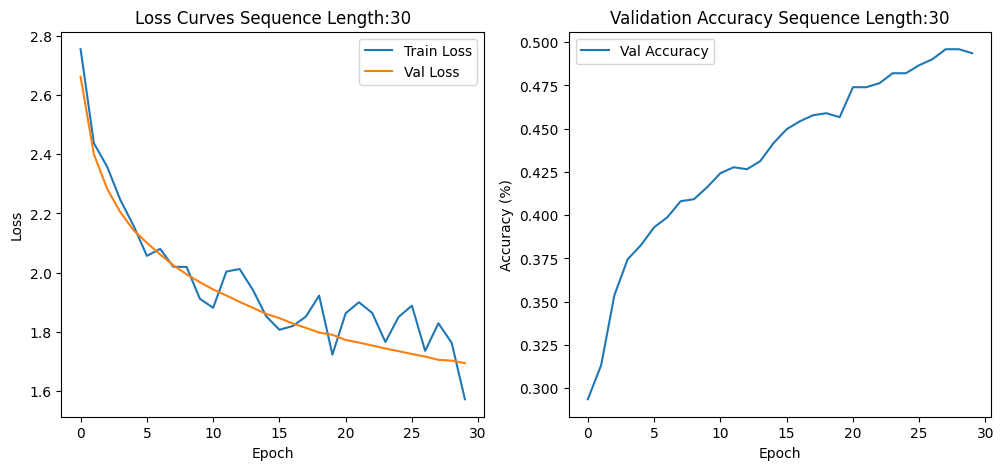

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 65]                   --
├─Embedding: 1-1                         [1, 30, 100]              6,500
├─LSTM: 1-2                              [1, 30, 100]              161,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 174,665
Trainable params: 174,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.86
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.70
Estimated Total Size (MB): 0.75
Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 2.7622, Val Accuracy: 0.2904, Val Loss: 2.5990, Training Time: 9304.0185546875ms
Epoch 1, Loss: 2.4398, Val Accuracy: 0.3380, Val Loss: 2.3232, Training Time: 9670.791015625ms
Epoch 2, Loss: 2.3715, Val Accuracy: 0.3647, Val Loss: 2.2116, Training Time: 9569.3046875ms
E

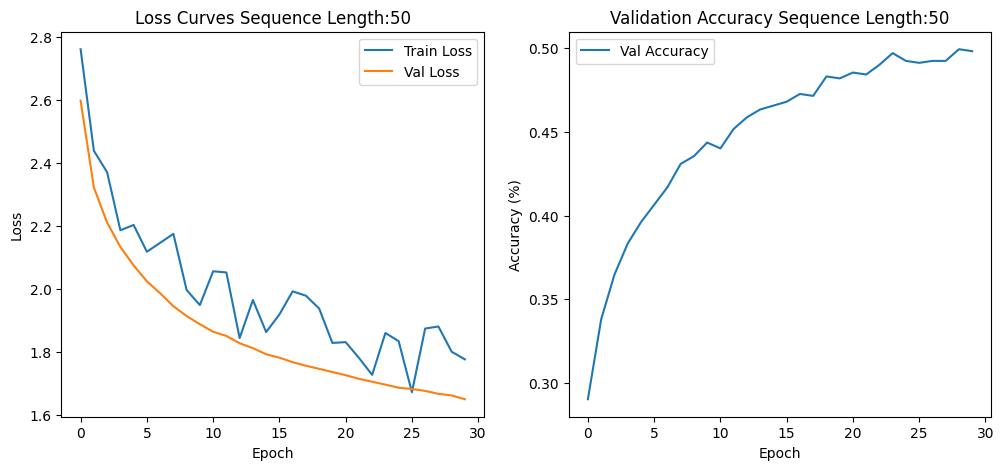

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 65]                   --
├─Embedding: 1-1                         [1, 50, 100]              6,500
├─LSTM: 1-2                              [1, 50, 100]              161,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 174,665
Trainable params: 174,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 8.09
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.70
Estimated Total Size (MB): 0.78


In [17]:
run("LSTM")

Train and Test Loader Created - Sequence Length: 20
Epoch 0, Loss: 2.5418, Val Accuracy: 0.3103, Val Loss: 2.5102, Training Time: 7218.9462890625ms
Epoch 1, Loss: 2.3356, Val Accuracy: 0.3564, Val Loss: 2.2894, Training Time: 8728.6669921875ms
Epoch 2, Loss: 2.2545, Val Accuracy: 0.3806, Val Loss: 2.1743, Training Time: 8733.3642578125ms
Epoch 3, Loss: 2.2337, Val Accuracy: 0.3910, Val Loss: 2.0971, Training Time: 8908.6953125ms
Epoch 4, Loss: 2.0493, Val Accuracy: 0.4014, Val Loss: 2.0428, Training Time: 8768.0419921875ms
Epoch 5, Loss: 1.9715, Val Accuracy: 0.4141, Val Loss: 2.0028, Training Time: 8702.0166015625ms
Epoch 6, Loss: 1.9528, Val Accuracy: 0.4233, Val Loss: 1.9717, Training Time: 8867.9609375ms
Epoch 7, Loss: 1.9875, Val Accuracy: 0.4337, Val Loss: 1.9381, Training Time: 8705.748046875ms
Epoch 8, Loss: 2.0523, Val Accuracy: 0.4383, Val Loss: 1.9087, Training Time: 8718.26171875ms
Epoch 9, Loss: 1.9953, Val Accuracy: 0.4521, Val Loss: 1.8915, Training Time: 8812.08984375ms

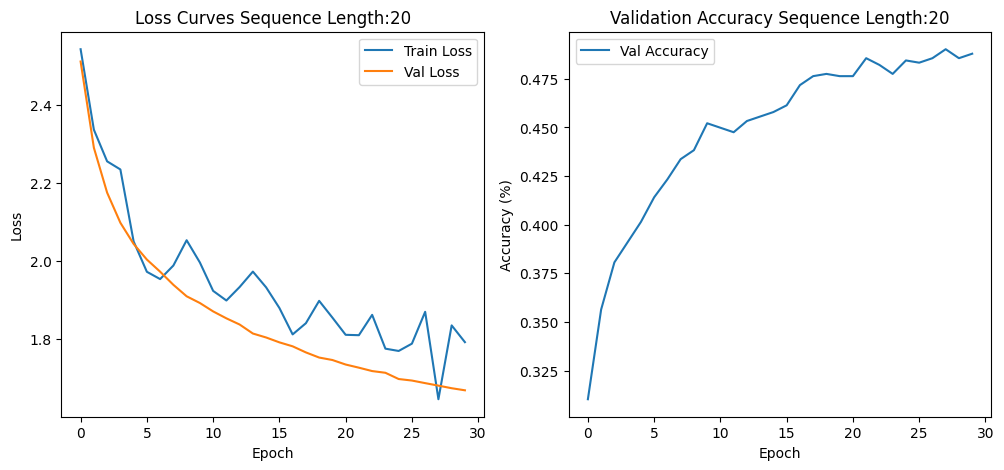

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 65]                   --
├─Embedding: 1-1                         [1, 20, 100]              6,500
├─GRU: 1-2                               [1, 20, 100]              121,200
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 134,265
Trainable params: 134,265
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.44
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.54
Estimated Total Size (MB): 0.57
Train and Test Loader Created - Sequence Length: 30
Epoch 0, Loss: 2.5164, Val Accuracy: 0.3202, Val Loss: 2.4796, Training Time: 8411.7783203125ms
Epoch 1, Loss: 2.4008, Val Accuracy: 0.3676, Val Loss: 2.2466, Training Time: 9001.4501953125ms
Epoch 2, Loss: 2.1086, Val Accuracy: 0.3896, Val Loss: 2.1304, Training Time: 9021.7607421875

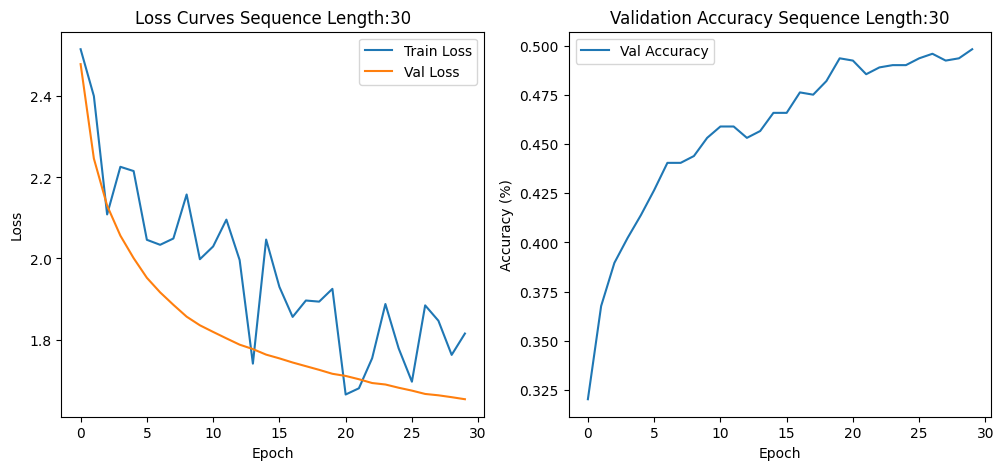

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 65]                   --
├─Embedding: 1-1                         [1, 30, 100]              6,500
├─GRU: 1-2                               [1, 30, 100]              121,200
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 134,265
Trainable params: 134,265
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.65
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.54
Estimated Total Size (MB): 0.59
Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 2.5402, Val Accuracy: 0.3078, Val Loss: 2.4606, Training Time: 7934.568359375ms
Epoch 1, Loss: 2.3188, Val Accuracy: 0.3612, Val Loss: 2.2292, Training Time: 9192.0908203125ms
Epoch 2, Loss: 2.3086, Val Accuracy: 0.3844, Val Loss: 2.1091, Training Time: 9184.349609375ms

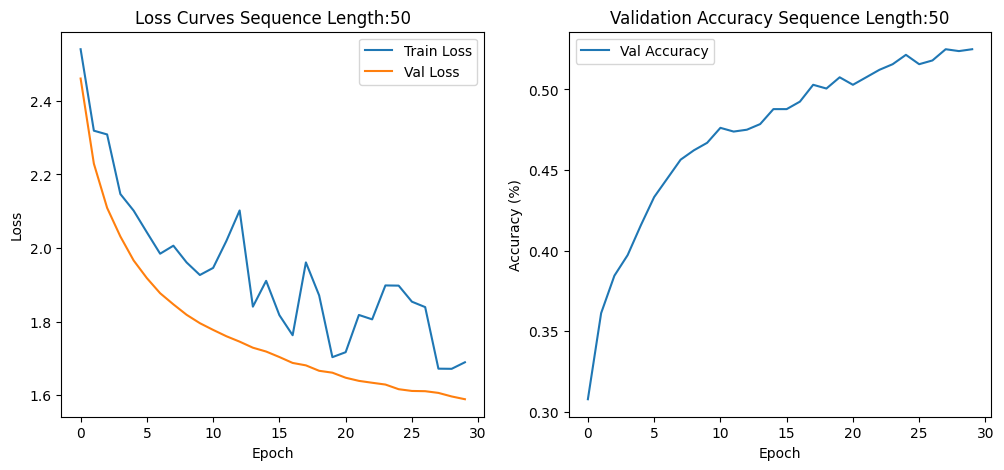

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 65]                   --
├─Embedding: 1-1                         [1, 50, 100]              6,500
├─GRU: 1-2                               [1, 50, 100]              121,200
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 134,265
Trainable params: 134,265
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.54
Estimated Total Size (MB): 0.62


In [18]:
run("GRU")